In [48]:
import time
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# Note: To import a function from another Jupyter Notebook,
# you typically need a package like 'importnb' or you can export
# your BFS notebook to a .py file.
# For this example, we assume you exported it to BFS_impl.py
from BFS_impl import bfs_path_to_target


def experiment_runner(board_configurations, end_row, optimal_moves):
    """
    Runs the BFS solver against a list of board configurations and tracks metrics.
    """
    results = []

    for idx, (board, op_moves) in enumerate(zip(board_configurations, optimal_moves)):
        print(f"Testing Board {idx + 1}...")

        # 1. Start memory tracking
        tracemalloc.start()

        # 2. Start time tracking
        start_time = time.perf_counter()

        # 3. RUN THE ALGORITHM
        # We assume your solve_function returns the solution sequence 'pi'
        # and the size of your 'ClosedSet' (number of visited states)
        sol = bfs_path_to_target(board, end_row)

        # 4. Stop time tracking
        end_time = time.perf_counter()

        # 5. Stop memory tracking and get the peak memory usage
        current_mem, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Calculate metrics
        runtime_seconds = end_time - start_time
        peak_memory_mb = peak_mem / (1024 * 1024)
        visited_states_count = sol
        moves_required = (len(sol) + 1) if sol else 1

        results.append({
            "Board ID": idx + 1,
            "Moves to Solve (T)": moves_required,
            "Difference from Optimal": moves_required - int(op_moves),
            "States Explored": visited_states_count,
            "Runtime (Seconds)": runtime_seconds,
            "Peak Memory (MB)": peak_memory_mb
        })

    return pd.DataFrame(results)

In [43]:
puzzles_4 = []
puzzles_4_op_moves = []

# load 4x4 puzzles with no walls
with open("../data/rush_4.txt", "r", encoding="utf-8") as fin:
    for line in fin:
        stripped = line.strip()
        if not stripped:
            continue

        parts = stripped.split(" ")
        moves, board = parts

        puzzles_4.append(board)
        puzzles_4_op_moves.append(moves)




In [45]:
puzzles_6 = []
puzzles_6_op_moves = []

# load 6x6 puzzles with no walls
with open("../data/rush_no_walls.txt", "r", encoding="utf-8") as fin:
    for line in fin:
        stripped = line.strip()
        if not stripped:
            continue

        parts = stripped.split(maxsplit=2)
        if len(parts) != 3:
            continue

        moves, board_desc, _ = parts
        puzzles_6.append(board_desc)
        puzzles_6_op_moves.append(moves)

In [47]:
1# Run the experiment
end_row = 2
df_results = experiment_runner(puzzles_6, end_row, puzzles_6_op_moves)

# Display the formatted DataFrame
display(df_results)

Testing Board 1...
Testing Board 2...
Testing Board 3...
Testing Board 4...
Testing Board 5...
Testing Board 6...
Testing Board 7...
Testing Board 8...
Testing Board 9...
Testing Board 10...
Testing Board 11...
Testing Board 12...
Testing Board 13...
Testing Board 14...
Testing Board 15...
Testing Board 16...
Testing Board 17...
Testing Board 18...
Testing Board 19...
Testing Board 20...
Testing Board 21...
Testing Board 22...
Testing Board 23...
Testing Board 24...
Testing Board 25...
Testing Board 26...
Testing Board 27...
Testing Board 28...
Testing Board 29...
Testing Board 30...
Testing Board 31...
Testing Board 32...
Testing Board 33...
Testing Board 34...
Testing Board 35...
Testing Board 36...
Testing Board 37...
Testing Board 38...
Testing Board 39...
Testing Board 40...
Testing Board 41...
Testing Board 42...
Testing Board 43...
Testing Board 44...
Testing Board 45...
Testing Board 46...
Testing Board 47...
Testing Board 48...
Testing Board 49...
Testing Board 50...
Testing B

KeyboardInterrupt: 

In [35]:
df_results.iloc[1]

Board ID                                                                   2
Moves to Solve (T)                                                         3
Difference from Optimal                                                   -2
States Explored            [oBoooooooEoCAoDo, oBooAooooEoCooDo, oBoooooAo...
Runtime (Seconds)                                                    0.00695
Peak Memory (MB)                                                    0.054193
Name: 1, dtype: object

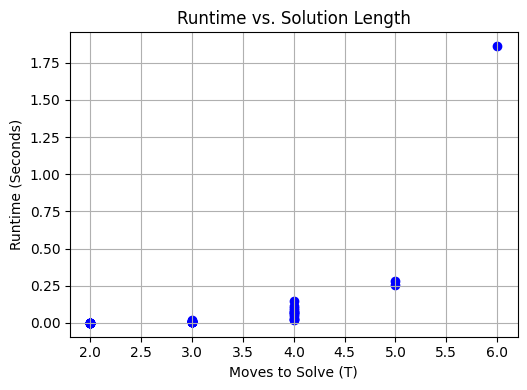

In [28]:
# ==========================================
# Visualization
# ==========================================
plt.figure(figsize=(10, 4))

# # Plot 1: States Explored vs Memory Used
# plt.subplot(1, 2, 1)
# plt.scatter(df_results["States Explored"], df_results["Peak Memory (MB)"], color='red')
# plt.title("Memory vs. Explored States")
# plt.xlabel("States Explored")
# plt.ylabel("Peak Memory (MB)")
# plt.grid(True)

# Plot 2: Path Length vs Runtime
plt.subplot(1, 2, 2)
plt.scatter(df_results["Moves to Solve (T)"], df_results["Runtime (Seconds)"], color='blue')
plt.title("Runtime vs. Solution Length")
plt.xlabel("Moves to Solve (T)")
plt.ylabel("Runtime (Seconds)")
plt.grid(True)

plt.tight_layout()
plt.show()